In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/Global_Supply_Chain_2024to2025.csv")
df["Date"] = pd.to_datetime(df["Date"])

df_clean = df.copy()

df_clean.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


### Definition der geopolitischen Risikogruppen

Der `Geopolitical_Risk_Score` liegt auf einer Skala von 0 bis 10.

Für die Analyse teilen wir den Score in drei gleich große Risikogruppen ein:

- **Niedrig:** 0 bis 3,33
- **Mittel:** 3,33 bis 6,67
- **Hoch:** ab 6,67 bis 10

Die Grenzen entstehen durch die Aufteilung der Skala 0–10 in drei gleich große Bereiche:

**10 / 3 = 3,33**

Damit ist **6,67 die Grenze zur Gruppe mit hohem geopolitischem Risiko**.

Anschließend vergleichen wir die beobachtete Unterbrechungsrate zwischen den drei Risikogruppen.

In [75]:
df_clean["Geo_Risk_Level"] = pd.cut(
    df_clean["Geopolitical_Risk_Score"],
    bins=[-0.01, 3.33, 6.67, 10],
    labels=["Low", "Medium", "High"]
)

geo_risk_summary = (
    df_clean.groupby("Geo_Risk_Level", observed=True)
    .agg(
        Shipment_Count=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean")
    )
    .reset_index()
)

geo_risk_summary["Disruption_Rate"] = (
    geo_risk_summary["Disruption_Rate"] * 100
).round(2)

geo_risk_summary

,Geo_Risk_Level,Shipment_Count,Disruption_Rate
0,Low,1596,47.24
1,Medium,1677,62.43
2,High,1727,73.07


In [76]:
risk_weather = pd.crosstab(
    [df_clean["Geo_Risk_Level"], df_clean["Weather_Condition"]],
    df_clean["Disruption_Occurred"],
    normalize="index"
)

risk_weather.round(3)

Disruption_Occurred                   0      1
Geo_Risk_Level Weather_Condition              
Low            Clear              0.776  0.224
               Fog                0.701  0.299
               Hurricane          0.000  1.000
               Rain               0.768  0.232
               Storm              0.373  0.627
Medium         Clear              0.633  0.367
               Fog                0.527  0.473
               Hurricane          0.000  1.000
               Rain               0.564  0.436
               Storm              0.184  0.816
High           Clear              0.484  0.516
               Fog                0.350  0.650
               Hurricane          0.000  1.000
               Rain               0.431  0.569
               Storm              0.067  0.933

In [77]:
risk_weather_counts = pd.crosstab(
    [df_clean["Geo_Risk_Level"], df_clean["Weather_Condition"]],
    df_clean["Disruption_Occurred"]
)

risk_weather_counts

Disruption_Occurred                 0    1
Geo_Risk_Level Weather_Condition          
Low            Clear              257   74
               Fog                227   97
               Hurricane            0  309
               Rain               238   72
               Storm              120  202
Medium         Clear              207  120
               Fog                184  165
               Hurricane            0  350
               Rain               177  137
               Storm               62  275
High           Clear              163  174
               Fog                127  236
               Hurricane            0  331
               Rain               152  201
               Storm               23  320

In [78]:
geo_risk_summary = df_clean.groupby("Geo_Risk_Level", observed=False).agg(
    Shipment_Count=("Disruption_Occurred", "size"), 
    Disruption_Rate=("Disruption_Occurred", "mean")
)

geo_risk_summary["Disruption_Rate"] = (
    geo_risk_summary["Disruption_Rate"] *  100
).round(1)

geo_risk_summary

,Shipment_Count,Disruption_Rate
Geo_Risk_Level,,
Low,1596,47.2
Medium,1677,62.4
High,1727,73.1


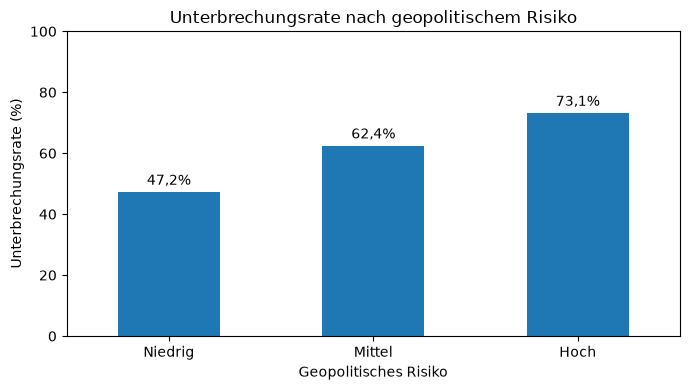

In [79]:
ax = geo_risk_summary["Disruption_Rate"].plot(
    kind="bar",
    figsize=(7,4),
    title="Unterbrechungsrate nach geopolitischem Risiko"
)

ax.set_xlabel("Geopolitisches Risiko")
ax.set_ylabel("Unterbrechungsrate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

# Risikostufen ins Deutsche übersetzen
ax.set_xticklabels(["Niedrig", "Mittel", "Hoch"])

# Prozentwerte mit einer Nachkommastelle anzeigen
for container in ax.containers:
    labels = [
        f"{value:.1f}%".replace(".", ",")
        for value in geo_risk_summary["Disruption_Rate"]
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.tight_layout()
plt.show()

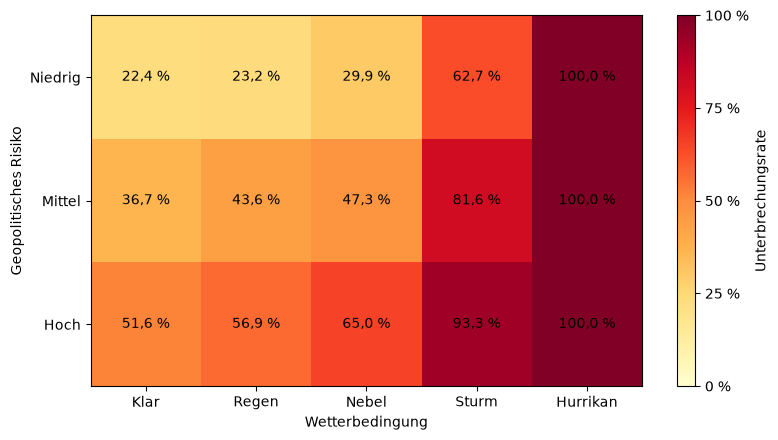

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Heatmap-Daten aus der bestehenden Analyse
risk_weather_rates = risk_weather[1].unstack()

# Wetterbedingungen ins Deutsche übersetzen
weather_labels = {
    "Clear": "Klar",
    "Rain": "Regen",
    "Fog": "Nebel",
    "Storm": "Sturm",
    "Hurricane": "Hurrikan"
}

# Geopolitische Risikostufen ins Deutsche übersetzen
risk_labels = {
    "Low": "Niedrig",
    "Medium": "Mittel",
    "High": "Hoch"
}

# Beschriftungen übersetzen
risk_weather_rates = risk_weather_rates.rename(
    columns=weather_labels,
    index=risk_labels
)

# Reihenfolge der Wetterbedingungen festlegen
weather_order = [
    "Klar",
    "Regen",
    "Nebel",
    "Sturm",
    "Hurrikan"
]

risk_weather_rates = risk_weather_rates[weather_order]

# Heatmap erstellen
fig, ax = plt.subplots(figsize=(8, 4.5))

heatmap = ax.imshow(
    risk_weather_rates,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    aspect="auto"
)

# X-Achse
ax.set_xticks(range(len(risk_weather_rates.columns)))
ax.set_xticklabels(risk_weather_rates.columns)

# Y-Achse
ax.set_yticks(range(len(risk_weather_rates.index)))
ax.set_yticklabels(risk_weather_rates.index)

# Achsenbeschriftungen
ax.set_xlabel("Wetterbedingung")
ax.set_ylabel("Geopolitisches Risiko")

# Kein zusätzlicher Titel im Diagramm
ax.set_title("")

# Prozentwerte in den Zellen anzeigen
for i in range(len(risk_weather_rates.index)):
    for j in range(len(risk_weather_rates.columns)):
        rate = risk_weather_rates.iloc[i, j]

        ax.text(
            j,
            i,
            f"{rate * 100:.1f} %".replace(".", ","),
            ha="center",
            va="center"
        )

# Farblegende mit Prozentwerten
cbar = fig.colorbar(
    heatmap,
    ax=ax,
    label="Unterbrechungsrate"
)

cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels([
    "0 %",
    "25 %",
    "50 %",
    "75 %",
    "100 %"
])

plt.tight_layout()
plt.show()

In [81]:
geo_leadtime_summary = df_clean.groupby("Geo_Risk_Level", observed=False).agg(
    Shipment_Count=("Lead_Time_Days", "count"),
    Mean_Lead_Time=("Lead_Time_Days", "mean"),
    Median_Lead_Time=("Lead_Time_Days", "median"),
    Disruption_Rate=("Disruption_Occurred", "mean")
)

geo_leadtime_summary.round(2)

,Shipment_Count,Mean_Lead_Time,Median_Lead_Time,Disruption_Rate
Geo_Risk_Level,,,,
Low,1596,15.63,6.86,0.47
Medium,1677,19.41,8.30,0.62
High,1727,22.74,9.52,0.73


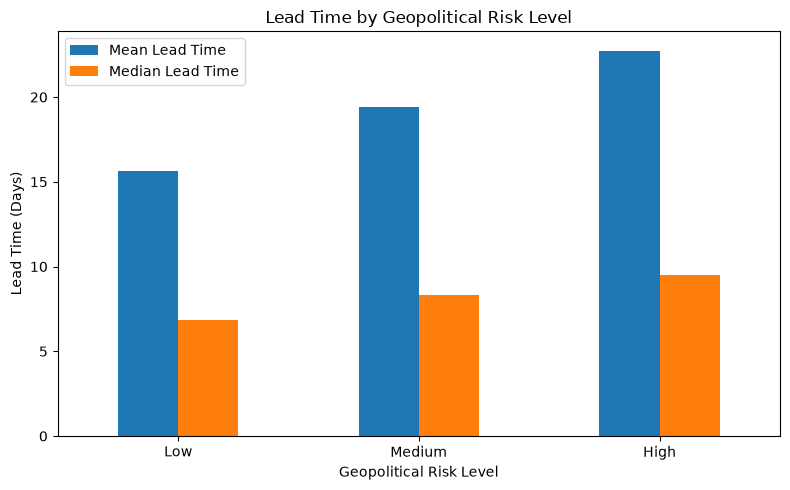

In [82]:
ax = geo_leadtime_summary[
    ["Mean_Lead_Time", "Median_Lead_Time"]
].plot(
    kind="bar",
    figsize=(8,5),
    title="Lead Time by Geopolitical Risk Level"
)

ax.set_xlabel("Geopolitical Risk Level")
ax.set_ylabel("Lead Time (Days)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Mean Lead Time", "Median Lead Time"])

plt.tight_layout()
plt.show()

In [83]:
leadtime_by_risk_weather  = df_clean.groupby(
    ["Geo_Risk_Level", "Weather_Condition"],
    observed=False
).agg(
    Shipment_Count=("Lead_Time_Days", "count"), 
    Median_Lead_Time=("Lead_Time_Days", "median"),
    Mean_Lead_Time=("Lead_Time_Days", "mean")
).round(2)

leadtime_by_risk_weather

Shipment_Count  Median_Lead_Time  \
Geo_Risk_Level Weather_Condition                                     
Low            Clear                         331              4.78   
               Fog                           324              5.56   
               Hurricane                     309             31.96   
               Rain                          310              4.51   
               Storm                         322             11.01   
Medium         Clear                         327              4.51   
               Fog                           349              6.29   
               Hurricane                     350             40.02   
               Rain                          314              6.46   
               Storm                         337             17.81   
High           Clear                         337              5.74   
               Fog                           363              8.93   
               Hurricane                     331             48.15   
               Rain                          353              7.17   
               Storm                         343             17.22   

                                  Mean_Lead_Time  
Geo_Risk_Level Weather_Condition                  
Low            Clear                        6.06  
               Fog                          7.84  
               Hurricane                   43.86  
               Rain                         6.46  
               Storm                       15.06  
Medium         Clear                        6.64  
               Fog                          9.52  
               Hurricane                   50.85  
               Rain                         7.98  
               Storm                       20.04  
High           Clear                        7.38  
               Fog                         12.08  
               Hurricane                   65.31  
               Rain                         8.64  
               Storm                       22.55

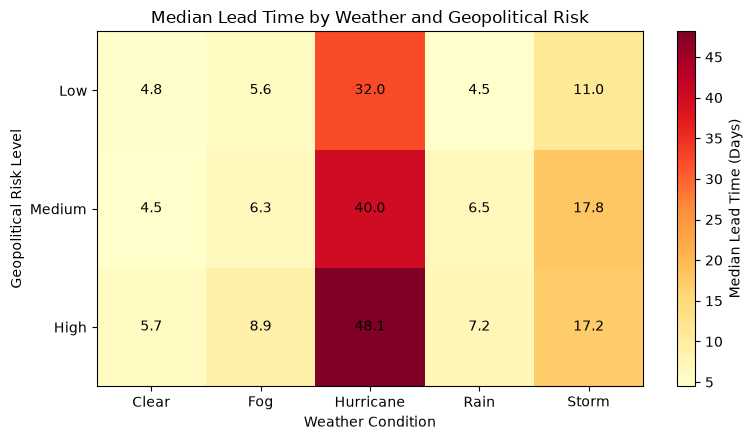

In [84]:
leadtime_median_matrix = leadtime_by_risk_weather[
    "Median_Lead_Time"
].unstack()

fig, ax = plt.subplots(figsize=(8, 4.5))

heatmap = ax.imshow(
    leadtime_median_matrix, 
    cmap="YlOrRd",
    aspect="auto"
)

ax.set_xticks(range(len(leadtime_median_matrix.columns)))
ax.set_xticklabels(leadtime_median_matrix.columns)

ax.set_yticks(range(len(leadtime_median_matrix.index)))
ax.set_yticklabels(leadtime_median_matrix.index)

ax.set_xlabel("Weather Condition")
ax.set_ylabel("Geopolitical Risk Level")
ax.set_title("Median Lead Time by Weather and Geopolitical Risk")

for i in range (len(leadtime_median_matrix.index)):
    for j in range(len(leadtime_median_matrix.columns)):
        value = leadtime_median_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.1f}", ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label= "Median Lead Time (Days)")
plt.tight_layout()
plt.show()

In [85]:
df_clean["Carrier_Reliability_Level"] = pd.cut(
    df_clean["Carrier_Reliability_Score"],
    bins=[0, 0.67, 0.84, 1.01],
    labels=["Low", "Medium", "High"],
    right=False
)

df_clean["Carrier_Reliability_Level"].value_counts().sort_index()

Carrier_Reliability_Level
Low       1644
Medium    1698
High      1658
Name: count, dtype: int64

In [86]:
carrier_risk_summary = df_clean.groupby(
    "Carrier_Reliability_Level",
    observed=False
).agg(
    Shipment_Count=("Disruption_Occurred", "size"),
    Disruption_Rate=("Disruption_Occurred", "mean")
)

carrier_risk_summary["Disruption_Rate"] = (
    carrier_risk_summary["Disruption_Rate"] * 100
).round(1)

carrier_risk_summary

,Shipment_Count,Disruption_Rate
Carrier_Reliability_Level,,
Low,1644,65.0
Medium,1698,63.0
High,1658,55.8


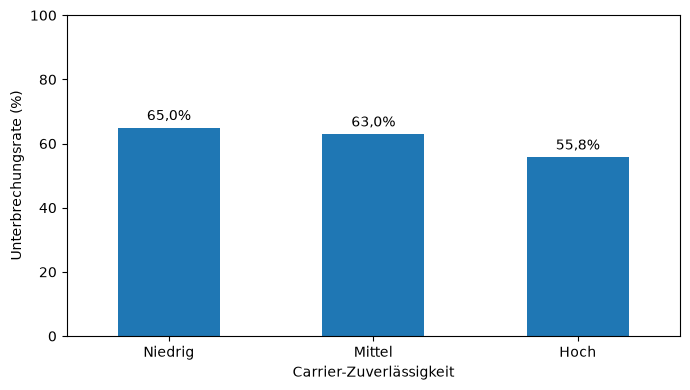

In [87]:
ax = carrier_risk_summary["Disruption_Rate"].plot(
    kind="bar",
    figsize=(7, 4),
    title=""
)

ax.set_xlabel("Carrier-Zuverlässigkeit")
ax.set_ylabel("Unterbrechungsrate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

# Englische Kategorien ins Deutsche übersetzen
ax.set_xticklabels(["Niedrig", "Mittel", "Hoch"])

# Prozentwerte mit einer Nachkommastelle anzeigen
for container in ax.containers:
    labels = [
        f"{value:.1f}%".replace(".", ",")
        for value in carrier_risk_summary["Disruption_Rate"]
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.tight_layout()
plt.show()

In [88]:
carrier_weather_summary = df_clean.groupby(
    ["Weather_Condition", "Carrier_Reliability_Level"],
    observed=False
).agg(
    Shipment_Count=("Disruption_Occurred", "size"),
    Disruption_Rate=("Disruption_Occurred", "mean")
)

carrier_weather_summary["Disruption_Rate"] = (
    carrier_weather_summary["Disruption_Rate"] * 100
).round(1)

carrier_weather_summary

Shipment_Count  Disruption_Rate
Weather_Condition Carrier_Reliability_Level                                 
Clear             Low                                   317             41.6
                  Medium                                336             39.3
                  High                                  342             30.4
Fog               Low                                   334             53.3
                  Medium                                369             48.8
                  High                                  333             42.0
Hurricane         Low                                   335            100.0
                  Medium                                344            100.0
                  High                                  311            100.0
Rain              Low                                   332             46.1
                  Medium                                306             45.1
                  High                                  339             35.1
Storm             Low                                   326             83.1
                  Medium                                343             80.2
                  High                                  333             75.4

In [89]:
carrier_geo_summary = df_clean.groupby(
    ["Geo_Risk_Level", "Carrier_Reliability_Level"],
    observed=False
).agg(
    Shipment_Count=("Disruption_Occurred", "size"),
    Disruption_Rate=("Disruption_Occurred", "mean")
)

carrier_geo_summary["Disruption_Rate"] = (
    carrier_geo_summary["Disruption_Rate"] * 100
).round(1)

carrier_geo_summary

Shipment_Count  Disruption_Rate
Geo_Risk_Level Carrier_Reliability_Level                                 
Low            Low                                   550             52.0
               Medium                                519             49.1
               High                                  527             40.4
Medium         Low                                   548             66.2
               Medium                                552             63.6
               High                                  577             57.7
High           Low                                   546             76.9
               Medium                                627             73.8
               High                                  554             68.4

## Zusammenfassung der Risikoanalyse

Die Analyse zeigt mehrere Zusammenhänge zwischen den untersuchten Faktoren und Lieferunterbrechungen:

- **Geopolitisches Risiko:** Der Anteil unterbrochener Lieferungen steigt von 47,2 % bei niedrigem Risiko auf 73,1 % bei hohem Risiko.
- **Wetterbedingungen:** Bei Hurrikanen wurden in diesem Datensatz alle Lieferungen als unterbrochen erfasst. Auch bei Stürmen war der Anteil hoch.
- **Zuverlässigkeit des Transportdienstleisters:** Bei einer hohen Zuverlässigkeitsbewertung lag die Unterbrechungsrate bei 55,8 %, verglichen mit 65,0 % bei einer niedrigen Bewertung.
- **Kombinierte Betrachtung:** Die Muster bleiben in mehreren Wetter- und Risikogruppen sichtbar. Die Stärke des Zusammenhangs unterscheidet sich jedoch je nach Gruppe.

### Interpretation und Einschränkungen

Die Ergebnisse zeigen Zusammenhänge, beweisen aber keine Ursache-Wirkungs-Beziehungen. Insbesondere die vollständige Unterbrechungsrate bei Hurrikanen sollte bei der späteren Modellierung genauer untersucht werden.

Die Analyse basiert auf den vorhandenen Daten für den Zeitraum 2024 bis 2025. Die Ergebnisse beschreiben diesen Datensatz und können nicht ohne weitere Prüfung auf alle Lieferketten übertragen werden.

### Nächster Schritt

Im nächsten Notebook wird untersucht, ob sich Lieferunterbrechungen anhand von Informationen vor oder zum Zeitpunkt einer möglichen Unterbrechung vorhersagen lassen. Dabei müssen Merkmale ausgeschlossen werden, die erst nach dem Ereignis bekannt sind.